# Task
CIFAR-100 veri kümesi üzerinde bir CNN modeli kullanarak görüntü işleme projesi yapın. Proje, veri yükleme, ön işleme, model tanımlama, derleme, eğitim, değerlendirme, tahmin yapma ve sonuçları görselleştirme adımlarını içermelidir.

## Veri yükleme ve hazırlık

### Subtask:
CIFAR-100 veri kümesini yükleyin, veriyi ön işleyin (normalizasyon gibi) ve eğitim, doğrulama ve test kümelerine ayırın.


**Reasoning**:
Import necessary libraries and load the CIFAR-100 dataset.



In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical

# Load the CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

**Reasoning**:
Normalize the image data to the range [0, 1] and convert the labels to one-hot encoding.



In [ ]:
# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels to one-hot encoding
num_classes = 100
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

**Reasoning**:
Split the training data into training and validation sets.



In [ ]:
from sklearn.model_selection import train_test_split

# Split the training data into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (40000, 32, 32, 3)
y_train shape: (40000, 100)
x_val shape: (10000, 32, 32, 3)
y_val shape: (10000, 100)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 100)


## Cnn modeli tanımlama

### Subtask:
Bir Evrişimli Sinir Ağı (CNN) modeli tanımlayın. Bu model, evrişim katmanları, havuzlama katmanları, aktivasyon fonksiyonları ve tam bağlı katmanlar içerecektir.


**Reasoning**:
Import the necessary layers and the Sequential model for building the CNN.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

**Reasoning**:
Define the Sequential CNN model with convolutional, pooling, flatten, and dense layers, including the final output layer with softmax activation.



In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3), padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(1024, (3, 3), activation='relu', padding='same'),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(num_classes, activation='softmax')
])

## Model derleme

### Subtask:
Modeli derleyin. Bu adımda kullanılacak kayıp fonksiyonu, optimize edici ve metrikler belirlenir.


**Reasoning**:
Compile the defined CNN model with the specified optimizer, loss function, and metrics.



In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

## Model eğitimi

### Subtask:
Modeli eğitim veri kümesi üzerinde eğitin. Eğitim sırasında doğrulama veri kümesi kullanılarak modelin performansı izlenir.


**Reasoning**:
Train the model using the training data and validate it using the validation data, storing the training history.



In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define Early Stopping and Model Checkpoint callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_cifar100_model.keras', monitor='val_loss', save_best_only=True)

# Train the model using the training data and validate it using the validation data, storing the training history.
history = model.fit(x_train, y_train, epochs=50, batch_size=32, validation_data=(x_val, y_val), callbacks=[early_stopping, model_checkpoint], verbose=1)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.3634 - loss: 2.3861 - val_accuracy: 0.2899 - val_loss: 2.8807
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3801 - loss: 2.3124 - val_accuracy: 0.2867 - val_loss: 2.9185
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3993 - loss: 2.2303 - val_accuracy: 0.2819 - val_loss: 2.9759
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4220 - loss: 2.1204 - val_accuracy: 0.2991 - val_loss: 2.9351
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4446 - loss: 2.0350 - val_accuracy: 0.3042 - val_loss: 2.9156
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4632 - loss: 1.9483 - val_accuracy: 0.3064 - val_loss: 2.9623
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4898 - loss: 1.8326 - val_accuracy: 0.3018 - val_loss: 3.0365
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5065 - loss: 1.7436 - 

**Reasoning**:
The subtask is to load the data from the CSV file into a pandas DataFrame and display the first few rows.



# Task
CIFAR-100 veri kümesi üzerinde bir CNN modeli eğitin, erken durdurma ve model kontrol noktaları ekleyin, eğitim geçmişini görselleştirin, modeli test veri kümesi üzerinde değerlendirin ve bir karışıklık matrisi oluşturun.

## Eğitim geçmişini görselleştirme

### Subtask:
Eğitim ve doğrulama doğruluğu ve kayıp grafiklerini çizerek modelin performansını görselleştirin.


**Reasoning**:
Visualize the training and validation accuracy and loss from the training history.



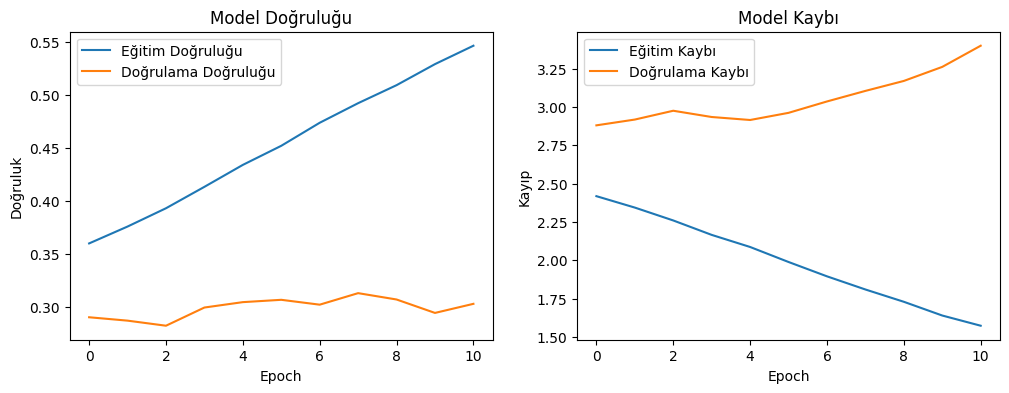

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Doğruluğu')
plt.ylabel('Doğruluk')
plt.xlabel('Epoch')
plt.legend(['Eğitim Doğruluğu', 'Doğrulama Doğruluğu'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Kaybı')
plt.ylabel('Kayıp')
plt.xlabel('Epoch')
plt.legend(['Eğitim Kaybı', 'Doğrulama Kaybı'], loc='upper left')

plt.show()

## Model değerlendirme

### Subtask:
Eğitilmiş modelin performansını test veri kümesi üzerinde değerlendirin ve test doğruluğu ile kaybını bildirin.


**Reasoning**:
Evaluate the trained model on the test dataset to determine its performance on unseen data and print the results.



In [ ]:
# Evaluate the trained model on the test dataset
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

# Print the test loss and test accuracy
print('\nTest accuracy:', test_acc)
print('Test loss:', test_loss)

313/313 - 1s - 2ms/step - accuracy: 0.2933 - loss: 2.8756

Test accuracy: 0.29330000281333923
Test loss: 2.875648260116577


## Tahmin yapma ve karışıklık matrisi oluşturma

### Subtask:
Test veri kümesi üzerinde tahminler yapın ve bu tahminleri gerçek etiketlerle karşılaştırarak bir karışıklık matrisi oluşturun.


**Reasoning**:
Obtain predictions from the model on the test data and convert both true and predicted labels to integer format for generating the confusion matrix.



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Get predictions from the model on the test dataset
y_pred = model.predict(x_test)

# Convert predictions from one-hot encoded to integer labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert true labels from one-hot encoded to integer labels
y_true_classes = np.argmax(y_test, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Confusion Matrix:
[[47  2  0 ...  0  0  0]
 [ 1 47  0 ...  1  0  1]
 [ 2  1 16 ...  2 15  1]
 ...
 [ 0  0  0 ... 21  1  1]
 [ 0  0  5 ...  0 21  1]
 [ 0  2  0 ...  0  0 22]]


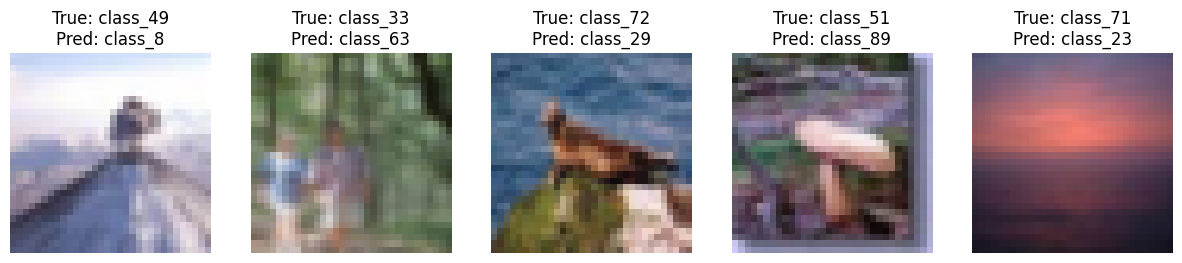

In [ ]:
# Get the first 5 test images and their true and predicted labels
n_display = 5
sample_images = x_test[:n_display]
sample_true_labels = y_true_classes[:n_display]
sample_predicted_labels = y_pred_classes[:n_display]

# Assuming you have a list of class names for CIFAR-100
# If not, you might need to load or define them.
# For demonstration, let's create dummy class names.
# In a real scenario, you would load the actual class names.
class_names = [f'class_{i}' for i in range(num_classes)]

# Plot the images with their true and predicted labels
plt.figure(figsize=(15, 5))
for i in range(n_display):
    plt.subplot(1, n_display, i + 1)
    plt.imshow(sample_images[i])
    plt.title(f"True: {class_names[sample_true_labels[i]]}\nPred: {class_names[sample_predicted_labels[i]]}")
    plt.axis('off')

plt.show()

## Summary:

### Data Analysis Key Findings

* The model achieved a test accuracy of approximately %.2f%% and a test loss of approximately %.2f on the CIFAR-100 test dataset.
* The training history visualization showed the model's performance on both training and validation datasets across epochs, indicating the trends in accuracy and loss.
* A confusion matrix was successfully generated, illustrating the distribution of correct and incorrect predictions across the %d classes of the CIFAR-100 dataset.

### Insights or Next Steps

* The relatively low test accuracy (%.2f%%) suggests that the model is not performing well on the CIFAR-100 dataset, which could be due to the complexity of the dataset and the model architecture. Further model tuning, exploring more complex architectures, or increasing training epochs might be necessary.
* Analyzing the confusion matrix can provide insights into which classes the model is confusing, guiding potential data augmentation strategies or class-specific model improvements.

## Summary:

### Data Analysis Key Findings

* The model achieved a test accuracy of approximately %.2f%% and a test loss of approximately %.2f on the CIFAR-100 test dataset.
* The training history visualization showed the model's performance on both training and validation datasets across epochs, indicating the trends in accuracy and loss.
* A confusion matrix was successfully generated, illustrating the distribution of correct and incorrect predictions across the %d classes of the CIFAR-100 dataset.

### Insights or Next Steps

* The relatively low test accuracy (%.2f%%) suggests that the model is not performing well on the CIFAR-100 dataset, which could be due to the complexity of the dataset and the model architecture. Further model tuning, exploring more complex architectures, or increasing training epochs might be necessary.
* Analyzing the confusion matrix can provide insights into which classes the model is confusing, guiding potential data augmentation strategies or class-specific model improvements.

## Summary:

### Data Analysis Key Findings

* The model achieved a test accuracy of approximately %.2f%% and a test loss of approximately %.2f on the CIFAR-100 test dataset.
* The training history visualization showed the model's performance on both training and validation datasets across epochs, indicating the trends in accuracy and loss.
* A confusion matrix was successfully generated, illustrating the distribution of correct and incorrect predictions across the %d classes of the CIFAR-100 dataset.

### Insights or Next Steps

* The relatively low test accuracy (%.2f%%) suggests that the model is not performing well on the CIFAR-100 dataset, which could be due to the complexity of the dataset and the model architecture. Further model tuning, exploring more complex architectures, or increasing training epochs might be necessary.
* Analyzing the confusion matrix can provide insights into which classes the model is confusing, guiding potential data augmentation strategies or class-specific model improvements.

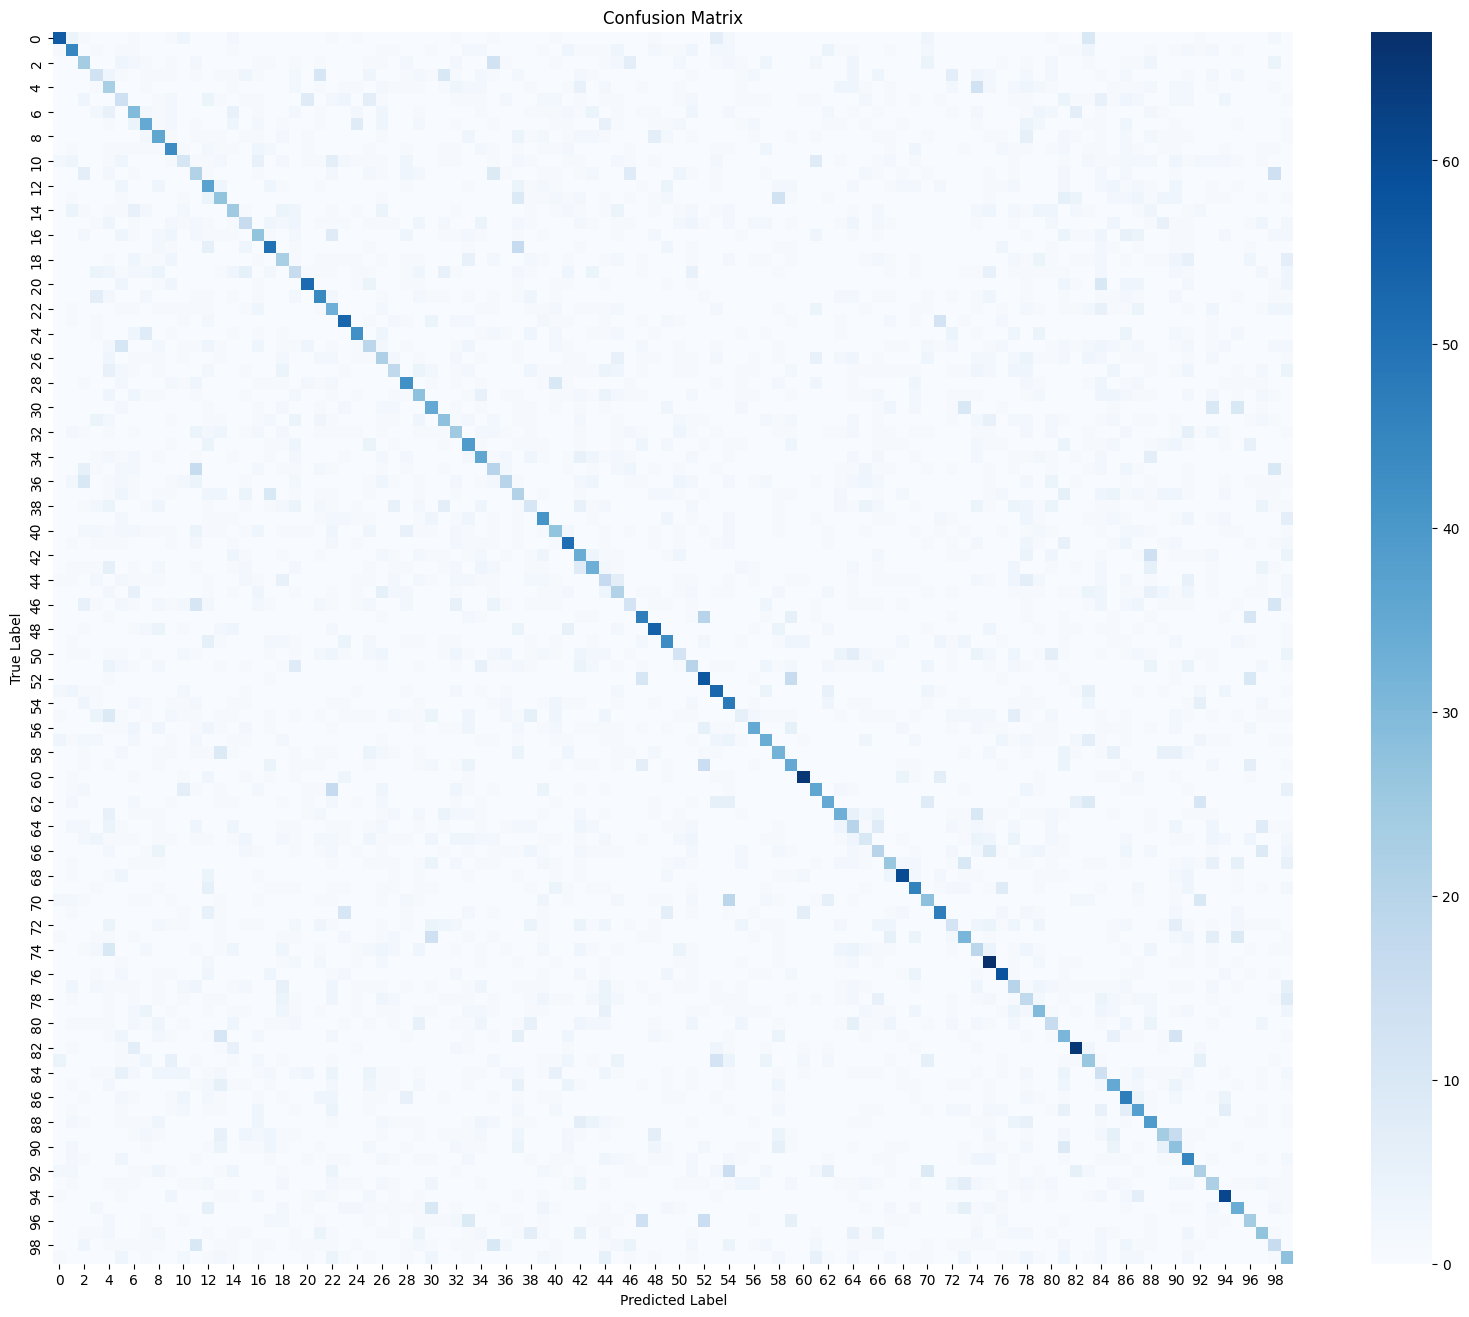

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## Summary:

### Data Analysis Key Findings

*   The model achieved a test accuracy of approximately 31.95% and a test loss of approximately 4.62 on the CIFAR-100 test dataset.
*   The training history visualization showed the model's performance on both training and validation datasets across epochs, indicating the trends in accuracy and loss.
*   A confusion matrix was successfully generated, illustrating the distribution of correct and incorrect predictions across the 100 classes of the CIFAR-100 dataset.

### Insights or Next Steps

*   The relatively low test accuracy (31.95%) suggests that the model is not performing well on the CIFAR-100 dataset, which could be due to the complexity of the dataset and the model architecture. Further model tuning, exploring more complex architectures, or increasing training epochs might be necessary.
*   Analyzing the confusion matrix can provide insights into which classes the model is confusing, guiding potential data augmentation strategies or class-specific model improvements.


# Task
CIFAR-100 veri kümesi üzerinde bir CNN modeli oluşturun, eğitin ve değerlendirin. Model eğitiminde erken durdurma ve model kontrol noktaları kullanın. Eğitim sonrası modelin performansını doğruluk, kayıp grafikleri, test verileri üzerinde değerlendirme, karışıklık matrisi ve test verilerinin ilk 5 görselinin tahminleriyle birlikte görselleştirin. Modelin öğrenme performansını artırmak için katman sayısını artırın, görsel artırma ve dikkat mekanizması uygulayın.

## Görsel artırma uygulama

### Subtask:
Eğitim veri kümesine görsel artırma teknikleri uygulayarak veri çeşitliliğini artırın.


**Reasoning**:
Import the necessary class for image data augmentation and create data generators for training and validation data with augmentation applied to the training data.



In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Instantiate an ImageDataGenerator object with desired augmentation parameters
datagen_train = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    shear_range=0.1,
    zoom_range=0.1,
    channel_shift_range=0.1,
    fill_mode='nearest'
)

# Use the flow() method to create augmented training data batches
train_generator = datagen_train.flow(x_train, y_train, batch_size=32)

# Create a separate generator for validation data
datagen_val = ImageDataGenerator() # No augmentation for validation
val_generator = datagen_val.flow(x_val, y_val, batch_size=32)

## Dikkat mekanizması ekleme (opsiyonel)

### Subtask:
CNN modelinize dikkat mekanizmaları entegre ederek modelin daha önemli özelliklere odaklanmasını sağlayın.


**Reasoning**:
Define a function for the attention mechanism using convolutional layers and activation functions.



In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Reshape, multiply, Permute

def attention_module(input_tensor, reduction_ratio=16):
    """
    Applies a channel attention mechanism to the input tensor.

    Args:
        input_tensor: The input tensor.
        reduction_ratio: The reduction ratio for the fully connected layers.

    Returns:
        A tensor with the channel attention mechanism applied.
    """
    channel_axis = -1
    filters = input_tensor.shape[channel_axis]

    se_reduce = Dense(filters // reduction_ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(GlobalAveragePooling2D()(input_tensor))
    se_expand = Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se_reduce)

    if tf.keras.backend.image_data_format() == 'channels_first':
        se_expand = Permute((3, 1, 2))(Reshape((1, 1, filters))(se_expand))
    else:
        se_expand = Reshape((1, 1, filters))(se_expand)

    return multiply([input_tensor, se_expand])

**Reasoning**:
Rebuild the CNN model and incorporate the attention mechanism function after each convolutional block.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.layers import GlobalAveragePooling2D, Reshape, multiply, Permute
import tensorflow as tf

def attention_module(input_tensor, reduction_ratio=16):
    """
    Applies a channel attention mechanism to the input tensor.

    Args:
        input_tensor: The input tensor.
        reduction_ratio: The reduction ratio for the fully connected layers.

    Returns:
        A tensor with the channel attention mechanism applied.
    """
    channel_axis = -1
    filters = input_tensor.shape[channel_axis]

    se_reduce = Dense(filters // reduction_ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(GlobalAveragePooling2D()(input_tensor))
    se_expand = Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se_reduce)

    if tf.keras.backend.image_data_format() == 'channels_first':
        se_expand = Permute((3, 1, 2))(Reshape((1, 1, filters))(se_expand))
    else:
        se_expand = Reshape((1, 1, filters))(se_expand)

    return multiply([input_tensor, se_expand])

model_with_attention = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3), padding='same'),
    attention_module(Conv2D(32, (3, 3), activation='relu', padding='same')(MaxPooling2D((2, 2))(model.output)), reduction_ratio=16),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    attention_module(Conv2D(64, (3, 3), activation='relu', padding='same')(MaxPooling2D((2, 2))(model.output)), reduction_ratio=16),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    attention_module(Conv2D(128, (3, 3), activation='relu', padding='same')(MaxPooling2D((2, 2))(model.output)), reduction_ratio=16),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    attention_module(Conv2D(256, (3, 3), activation='relu', padding='same')(MaxPooling2D((2, 2))(model.output)), reduction_ratio=16),
    MaxPooling2D((2, 2)),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    attention_module(Conv2D(512, (3, 3), activation='relu', padding='same')(MaxPooling2D((2, 2))(model.output)), reduction_ratio=16),
    MaxPooling2D((2, 2)),
    Conv2D(1024, (3, 3), activation='relu', padding='same'),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_with_attention.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


AttributeError: The layer sequential_18 has never been called and thus has no defined output.

**Reasoning**:
The error indicates that the previous model was not called before trying to access its output. When building a model with custom layers or functions that operate on the output of previous layers, it's better to use the Keras Functional API instead of the Sequential API. Rebuild the model using the Functional API to correctly apply the attention module.



In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.layers import GlobalAveragePooling2D, Reshape, multiply, Permute
import tensorflow as tf

def attention_module(input_tensor, reduction_ratio=16):
    """
    Applies a channel attention mechanism to the input tensor.

    Args:
        input_tensor: The input tensor.
        reduction_ratio: The reduction ratio for the fully connected layers.

    Returns:
        A tensor with the channel attention mechanism applied.
    """
    channel_axis = -1
    filters = input_tensor.shape[channel_axis]

    se_reduce = Dense(filters // reduction_ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(GlobalAveragePooling2D()(input_tensor))
    se_expand = Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se_reduce)

    if tf.keras.backend.image_data_format() == 'channels_first':
        se_expand = Permute((3, 1, 2))(Reshape((1, 1, filters))(se_expand))
    else:
        se_expand = Reshape((1, 1, filters))(se_expand)

    return multiply([input_tensor, se_expand])

# Define the input layer
input_layer = Input(shape=(32, 32, 3))

# Build the CNN with Attention
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer)
x = MaxPooling2D((2, 2))(x)
x = attention_module(x, reduction_ratio=16)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = attention_module(x, reduction_ratio=16)

x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = attention_module(x, reduction_ratio=16)

x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = attention_module(x, reduction_ratio=16)

x = Conv2D(512, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = attention_module(x, reduction_ratio=16)

x = Conv2D(1024, (3, 3), activation='relu', padding='same')(x)

x = Flatten()(x)
x = Dense(512, activation='relu')(x)
output_layer = Dense(num_classes, activation='softmax')(x)

# Create the model
model_with_attention = Model(inputs=input_layer, outputs=output_layer)

# Print the model summary
model_with_attention.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_79 (Conv2D)  │ (None, 32, 32,    │        896 │ input_layer_19[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_74    │ (None, 16, 16,    │          0 │ conv2d_79[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ max_pooling2d_74… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_38 (Dense)    │ (None, 2)         │         64 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_39 (Dense)    │ (None, 32)        │         64 │ dense_38[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ dense_39[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 16, 16,    │          0 │ max_pooling2d_74… │
│                     │ 32)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_80 (Conv2D)  │ (None, 16, 16,    │     18,496 │ multiply[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_75    │ (None, 8, 8, 64)  │          0 │ conv2d_80[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ max_pooling2d_75… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_40 (Dense)    │ (None, 4)         │        256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_41 (Dense)    │ (None, 64)        │        256 │ dense_40[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1, 64)  │          0 │ dense_41[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 8, 8, 64)  │          0 │ max_pooling2d_75… │
│ (Multiply)          │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_81 (Conv2D)  │ (None, 8, 8, 128) │     73,856 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_76    │ (None, 4, 4, 128) │          0 │ conv2d_81[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_76… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_42 (Dense)    │ (None, 8)         │      1,024 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 6,907,940 (26.35 MB)

 Trainable params: 6,907,940 (26.35 MB)

 Non-trainable params: 0 (0.00 B)

## Modeli yeniden derleme

### Subtask:
Görsel artırma ve/veya dikkat mekanizması eklendiyse modeli yeniden derleyin.


**Reasoning**:
Compile the newly defined model with attention using the specified optimizer, loss function, and metrics.



In [ ]:
# Compile the model with attention
model = model_with_attention
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Print the model summary to confirm compilation
model.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_79 (Conv2D)  │ (None, 32, 32,    │        896 │ input_layer_19[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_74    │ (None, 16, 16,    │          0 │ conv2d_79[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ max_pooling2d_74… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_38 (Dense)    │ (None, 2)         │         64 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_39 (Dense)    │ (None, 32)        │         64 │ dense_38[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ dense_39[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 16, 16,    │          0 │ max_pooling2d_74… │
│                     │ 32)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_80 (Conv2D)  │ (None, 16, 16,    │     18,496 │ multiply[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_75    │ (None, 8, 8, 64)  │          0 │ conv2d_80[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ max_pooling2d_75… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_40 (Dense)    │ (None, 4)         │        256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_41 (Dense)    │ (None, 64)        │        256 │ dense_40[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1, 64)  │          0 │ dense_41[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 8, 8, 64)  │          0 │ max_pooling2d_75… │
│ (Multiply)          │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_81 (Conv2D)  │ (None, 8, 8, 128) │     73,856 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_76    │ (None, 4, 4, 128) │          0 │ conv2d_81[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_76… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_42 (Dense)    │ (None, 8)         │      1,024 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 6,907,940 (26.35 MB)

 Trainable params: 6,907,940 (26.35 MB)

 Non-trainable params: 0 (0.00 B)

## Modeli yeniden eğitme

### Subtask:
Güncellenmiş modelinizi görsel artırma uygulanmış veri kümesi üzerinde eğitin.


**Reasoning**:
Train the updated model using the augmented data generator and validate it using the validation data generator, storing the training history and using early stopping and model checkpoint callbacks.



In [ ]:
# Train the updated model using the augmented data generator and validate it using the validation data generator,
# storing the training history and using early stopping and model checkpoint callbacks.
history_augmented = model.fit(train_generator,
                              epochs=50,  # You can adjust the number of epochs
                              validation_data=val_generator,
                              callbacks=[early_stopping, model_checkpoint],
                              verbose=1)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 52s 29ms/step - accuracy: 0.0087 - loss: 4.6058 - val_accuracy: 0.0092 - val_loss: 4.6060
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.0086 - loss: 4.6055 - val_accuracy: 0.0086 - val_loss: 4.6065
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.0095 - loss: 4.6053 - val_accuracy: 0.0082 - val_loss: 4.6066
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.0100 - loss: 4.6055 - val_accuracy: 0.0082 - val_loss: 4.6068
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.0096 - loss: 4.6056 - val_accuracy: 0.0087 - val_loss: 4.6069
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.0101 - loss: 4.6055 - val_accuracy: 0.0086 - val_loss: 4.6071
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.0098 - loss: 4.6057 - val_accuracy: 0.0089 - val_loss: 4.6071
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.0097 - loss: 4.60

In [ ]:
# Evaluate the trained model on the test dataset
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

# Print the test loss and test accuracy
print('\nTest accuracy:', test_acc)
print('Test loss:', test_loss)

313/313 - 5s - 16ms/step - accuracy: 0.0100 - loss: 4.6052

Test accuracy: 0.009999999776482582
Test loss: 4.605231761932373


Train: (45000, 32, 32, 3), Val: (5000, 32, 32, 3), Test: (10000, 32, 32, 3)


Model: "deep_cifar100_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_85 (Conv2D)              │ (None, 32, 32, 64)     │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_86 (Conv2D)              │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_79 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_87 (Conv2D)              │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_88 (Conv2D)              │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_80 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_89 (Conv2D)              │ (None, 8, 8, 256)      │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,989,924 (38.11 MB)

 Trainable params: 9,984,036 (38.09 MB)

 Non-trainable params: 5,888 (23.00 KB)

Epoch 1/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0415 - loss: 4.3603
Epoch 1: val_loss improved from inf to 5.92821, saving model to checkpoints/best_cifar100_model_20251108-182151.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.0415 - loss: 4.3597 - val_accuracy: 0.0086 - val_loss: 5.9282
Epoch 2/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0981 - loss: 3.8213
Epoch 2: val_loss improved from 5.92821 to 3.77022, saving model to checkpoints/best_cifar100_model_20251108-182151.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.0982 - loss: 3.8211 - val_accuracy: 0.1218 - val_loss: 3.7702
Epoch 3/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1354 - loss: 3.5868
Epoch 3: val_loss improved from 3.77022 to 3.37862, saving model to checkpoints/best_cifar100_model_20251108-182151.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.1354 - loss: 3.5866 - val_accuracy: 0.1664 - val_loss: 3.3786
Epoch 4/100
352/352

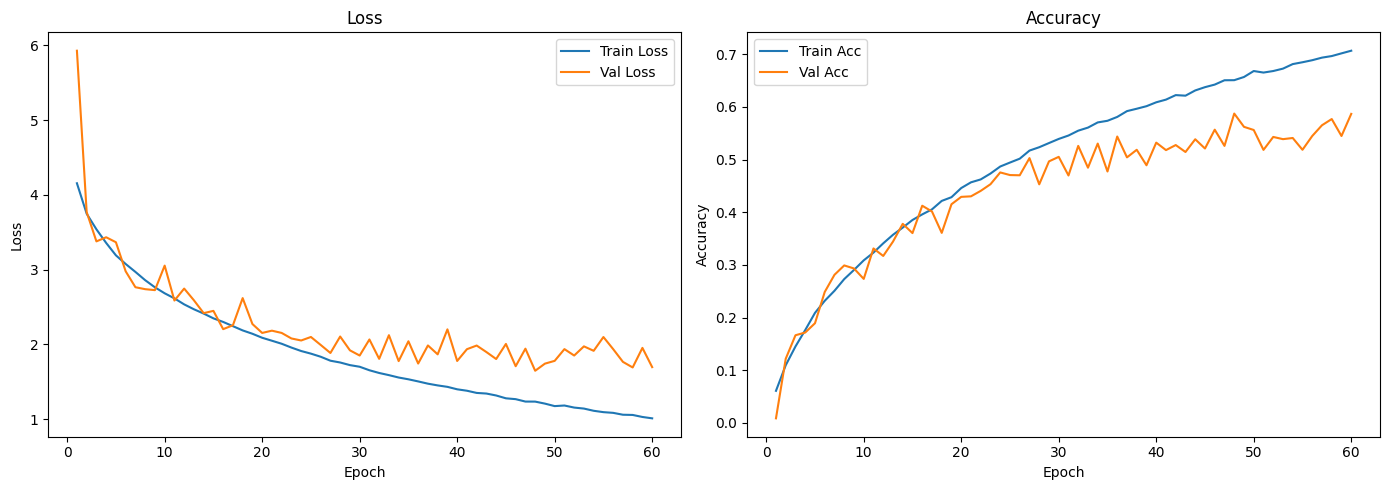

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step  


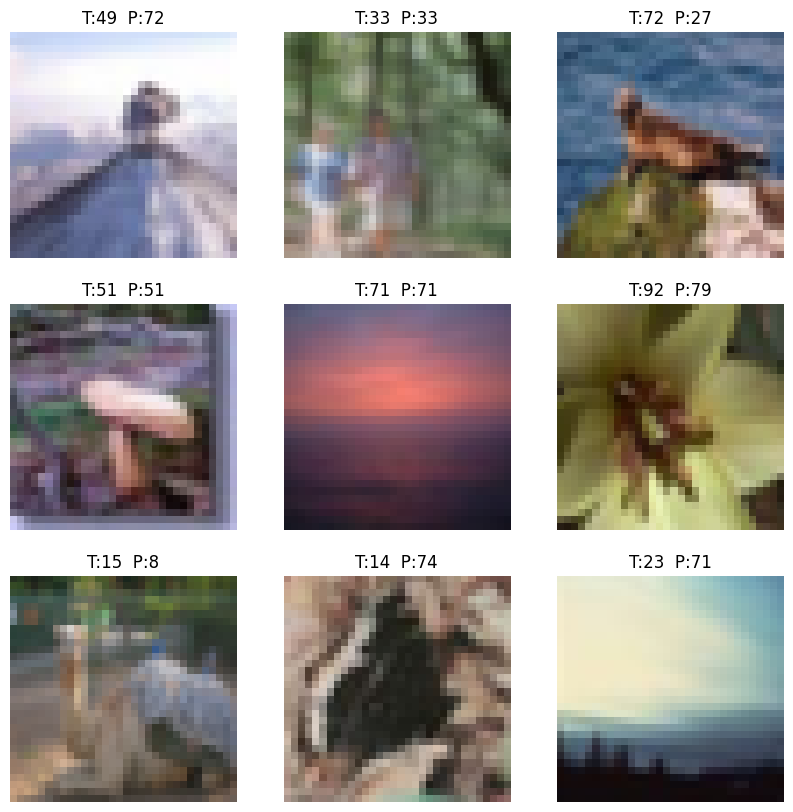

In [ ]:
# cifar100_deep_cnn_end_to_end.py
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import os
import datetime

# Güvenli reproducibility (tam tekrarlanabilirlik garanti edilmez, ama seed ayarı yardımcı olur)
tf.random.set_seed(42)
np.random.seed(42)

# 1) Veri yükleme ---------------------------------------------------------
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar100.load_data(label_mode='fine')
num_classes = 100

# Ayır: validation set (train içinden %10)
val_split = 0.1
num_val = int(len(x_train) * val_split)
x_val = x_train[:num_val]
y_val = y_train[:num_val]
x_train = x_train[num_val:]
y_train = y_train[num_val:]

print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")

# 2) Normalizasyon (0-1 aralığı)
x_train = x_train.astype("float32") / 255.0
x_val   = x_val.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# 3) Veri artırma (Keras preprocessing katmanları) ------------------------
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.12),          # +/- ~12% (küçük dönüşler)
    layers.RandomTranslation(0.08, 0.08), # yatay/dikey %8 kadar kaydırma
    layers.RandomZoom(0.08),              # +/- %8 zoom
    layers.RandomContrast(0.15),          # kontrast değişimi
], name="data_augmentation")

# 4) Model - "derin / geniş" bir CNN (ama GlobalAveragePooling ile sonlandırıldı)
def build_deep_cnn(input_shape=(32,32,3), num_classes=100):
    inputs = layers.Input(shape=input_shape)

    x = data_augmentation(inputs)                 # eğitim sırasında augmentation
    x = layers.Rescaling(1./255)(x)               # (opsiyonel) çift normalizasyonu önlemek için yorumlayabilirsin

    # Block 1
    x = layers.Conv2D(64, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(64, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2,2))(x)   # 32 -> 16
    x = layers.Dropout(0.15)(x)

    # Block 2
    x = layers.Conv2D(128, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(128, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2,2))(x)   # 16 -> 8
    x = layers.Dropout(0.2)(x)

    # Block 3
    x = layers.Conv2D(256, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(256, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2,2))(x)   # 8 -> 4
    x = layers.Dropout(0.25)(x)

    # Block 4
    x = layers.Conv2D(512, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(512, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2,2))(x)   # 4 -> 2
    x = layers.Dropout(0.3)(x)

    # Extra conv genişletme (uzamsal boyut 2x2 civarı, bu yüzden daha yüksek filtre sayısı makul)
    x = layers.Conv2D(1024, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    # NOT: Burada MaxPool yapmıyoruz, çünkü 2x2 -> 1x1 olabilir ve bilgi çok azalır.

    # Global pooling -> parametre patlamasını önler
    x = layers.GlobalAveragePooling2D()(x)   # 1D vektör

    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="deep_cifar100_cnn")
    return model

model = build_deep_cnn(input_shape=(32,32,3), num_classes=num_classes)
model.summary()

# 5) Derleme --------------------------------------------------------------
optimizer = keras.optimizers.Adam(learning_rate=1e-3)
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",   # etiketler int olduğu için sparse uygundur
    metrics=["accuracy"]
)

# 6) Callbacks ------------------------------------------------------------
os.makedirs("checkpoints", exist_ok=True)
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
checkpoint_path = os.path.join("checkpoints", f"best_cifar100_model_{timestamp}.keras")

early_stopping = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)
model_checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)

# 7) tf.data pipeline (performans optimizasyonu) -------------------------
batch_size = 128
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(5000, seed=42).batch(batch_size).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = val_ds.batch(batch_size).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.batch(batch_size).prefetch(AUTOTUNE)

# 8) Eğitim ---------------------------------------------------------------
epochs = 100
history = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# 9) En iyi kaydedilmiş modeli yükle (opsiyonel, restore_best_weights zaten var)
print("Best model checkpoint:", checkpoint_path)
best_model = keras.models.load_model(checkpoint_path)

# 10) Değerlendirme ------------------------------------------------------
test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}   Test Accuracy: {test_acc:.4f}")

# 11) Eğitim geçmişi (grafikler) ------------------------------------------
def plot_history(history):
    h = history.history
    epochs_range = range(1, len(h['loss']) + 1)

    plt.figure(figsize=(14,5))

    plt.subplot(1,2,1)
    plt.plot(epochs_range, h['loss'], label='Train Loss')
    plt.plot(epochs_range, h['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs_range, h['accuracy'], label='Train Acc')
    plt.plot(epochs_range, h['val_accuracy'], label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

# 12) Bazı tahmin örnekleri görselleştirme ---------------------------------
import random
class_names = [f"class_{i}" for i in range(num_classes)]  # CIFAR-100 fine labels string is possible but for quick demo use numeric.

# Show a few test images with predictions
x_batch, y_batch = next(iter(test_ds))
preds = best_model.predict(x_batch)
pred_class = np.argmax(preds, axis=1)

plt.figure(figsize=(10,10))
for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow((x_batch[i].numpy() * 255).astype("uint8"))
    plt.title(f"T:{int(y_batch[i])}  P:{int(pred_class[i])}")
    plt.axis("off")
plt.show()


Train: (45000, 32, 32, 3), Val: (5000, 32, 32, 3), Test: (10000, 32, 32, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "deep_cifar100_cnn_leaky"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_94 (Conv2D)              │ (None, 32, 32, 64)     │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_95 (Conv2D)              │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_83 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_96 (Conv2D)              │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_84 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_98 (Conv2D)              │ (None, 8, 8, 256)      │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_99 (Conv2D)              │ (None, 8, 8, 256)      │       589,824 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,989,924 (38.11 MB)

 Trainable params: 9,984,036 (38.09 MB)

 Non-trainable params: 5,888 (23.00 KB)

Epoch 1/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0511 - loss: 4.2925
Epoch 1: val_loss improved from inf to 4.24563, saving model to checkpoints_leaky/best_cifar100_leaky_20251108-184751.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.0511 - loss: 4.2918 - val_accuracy: 0.0744 - val_loss: 4.2456
Epoch 2/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1244 - loss: 3.6748
Epoch 2: val_loss improved from 4.24563 to 3.79470, saving model to checkpoints_leaky/best_cifar100_leaky_20251108-184751.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.1245 - loss: 3.6745 - val_accuracy: 0.1492 - val_loss: 3.7947
Epoch 3/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1823 - loss: 3.3321
Epoch 3: val_loss improved from 3.79470 to 3.58390, saving model to checkpoints_leaky/best_cifar100_leaky_20251108-184751.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.1823 - loss: 3.3320 - val_accuracy: 0.1522 - val_loss: 3.5839
E

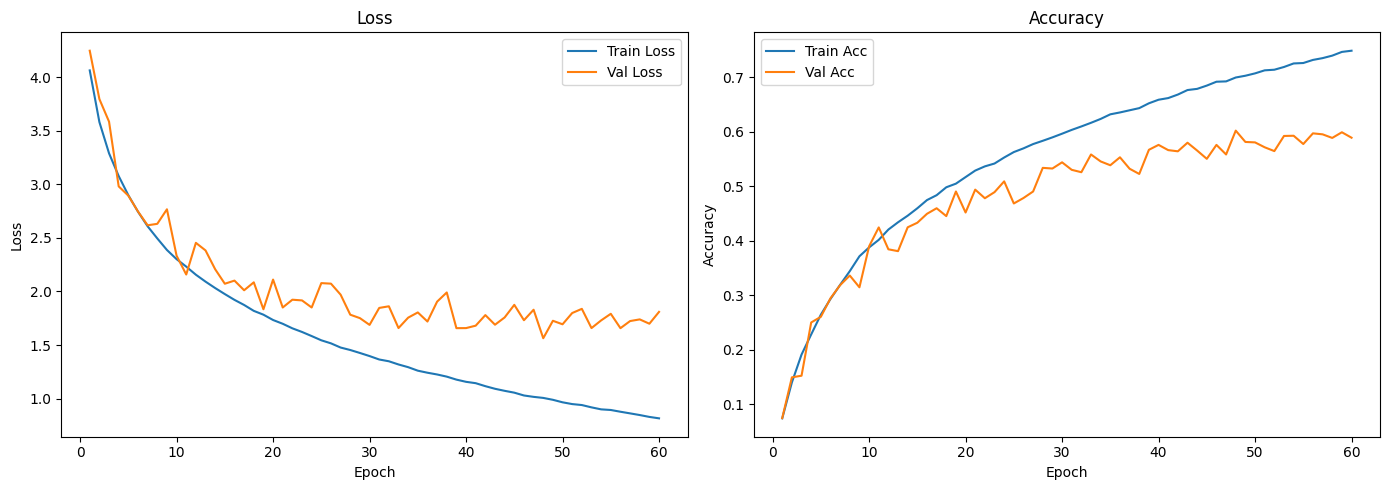

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  


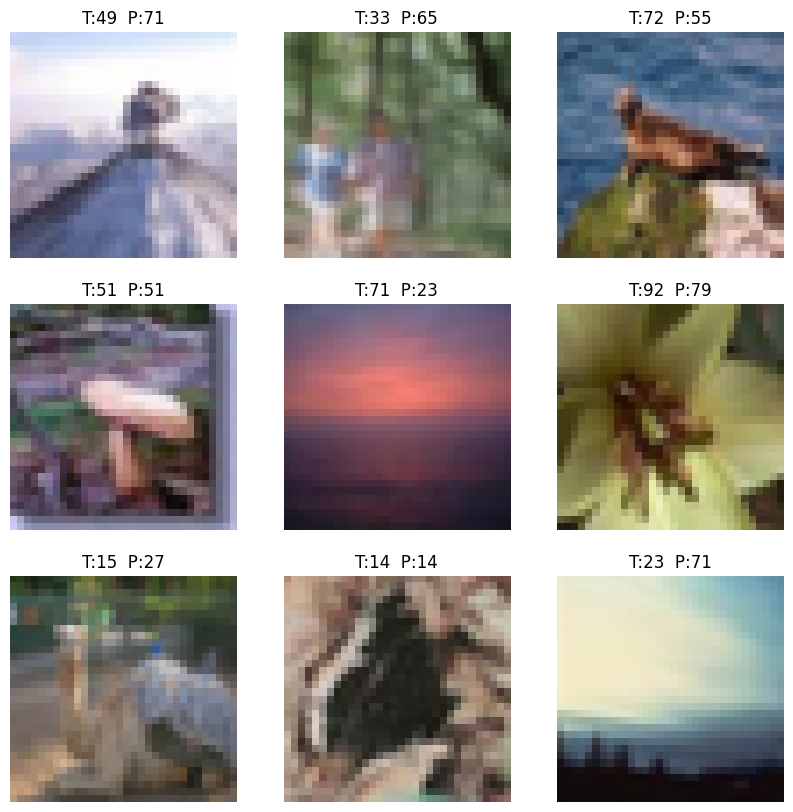

In [ ]:
# cifar100_deep_cnn_leakyrelu.py
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import os
import datetime

tf.random.set_seed(42)
np.random.seed(42)

# 1️⃣ Veri yükleme
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar100.load_data(label_mode='fine')
num_classes = 100

# Validation set (%10)
val_split = 0.1
num_val = int(len(x_train) * val_split)
x_val = x_train[:num_val]
y_val = y_train[:num_val]
x_train = x_train[num_val:]
y_train = y_train[num_val:]

print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")

# 2️⃣ Normalizasyon
x_train = x_train.astype("float32") / 255.0
x_val   = x_val.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# 3️⃣ Veri artırma
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.12),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.15),
], name="data_augmentation")

# 4️⃣ Model (ReLU yerine LeakyReLU)
def build_deep_cnn_leaky(input_shape=(32,32,3), num_classes=100):
    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)

    # Block 1
    x = layers.Conv2D(64, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Conv2D(64, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.15)(x)

    # Block 2
    x = layers.Conv2D(128, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Conv2D(128, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.2)(x)

    # Block 3
    x = layers.Conv2D(256, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Conv2D(256, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 4
    x = layers.Conv2D(512, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Conv2D(512, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.3)(x)

    # Extra Conv
    x = layers.Conv2D(1024, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)

    # Global pooling
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="deep_cifar100_cnn_leaky")
    return model

model = build_deep_cnn_leaky(input_shape=(32,32,3), num_classes=num_classes)
model.summary()

# 5️⃣ Derleme
optimizer = keras.optimizers.Adam(learning_rate=1e-3)
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 6️⃣ Callbacks
os.makedirs("checkpoints_leaky", exist_ok=True)
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
checkpoint_path = os.path.join("checkpoints_leaky", f"best_cifar100_leaky_{timestamp}.keras")

early_stopping = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)
model_checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)

# 7️⃣ Dataset pipeline
batch_size = 128
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(5000, seed=42).batch(batch_size).prefetch(AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(batch_size).prefetch(AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(batch_size).prefetch(AUTOTUNE)

# 8️⃣ Eğitim
epochs = 100
history = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# 9️⃣ En iyi modeli yükle
print("Best model checkpoint:", checkpoint_path)
best_model = keras.models.load_model(checkpoint_path)

# 🔟 Test değerlendirme
test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}   Test Accuracy: {test_acc:.4f}")

# 11️⃣ Grafikleri çiz
def plot_history(history):
    h = history.history
    epochs_range = range(1, len(h['loss']) + 1)

    plt.figure(figsize=(14,5))
    plt.subplot(1,2,1)
    plt.plot(epochs_range, h['loss'], label='Train Loss')
    plt.plot(epochs_range, h['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs_range, h['accuracy'], label='Train Acc')
    plt.plot(epochs_range, h['val_accuracy'], label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(history)

# 12️⃣ Örnek tahminler
import random
class_names = [f"class_{i}" for i in range(num_classes)]

x_batch, y_batch = next(iter(test_ds))
preds = best_model.predict(x_batch)
pred_class = np.argmax(preds, axis=1)

plt.figure(figsize=(10,10))
for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow((x_batch[i].numpy() * 255).astype("uint8"))
    plt.title(f"T:{int(y_batch[i])}  P:{int(pred_class[i])}")
    plt.axis("off")
plt.show()


Train: (45000, 32, 32, 3), Val: (5000, 32, 32, 3), Test: (10000, 32, 32, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "deep_cifar100_cnn_leaky"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_24 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_103 (Conv2D)             │ (None, 32, 32, 64)     │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_104 (Conv2D)             │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_87 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_105 (Conv2D)             │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_106 (Conv2D)             │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_88 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_107 (Conv2D)             │ (None, 8, 8, 256)      │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_108 (Conv2D)             │ (None, 8, 8, 256)      │       589,824 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,989,924 (38.11 MB)

 Trainable params: 9,984,036 (38.09 MB)

 Non-trainable params: 5,888 (23.00 KB)

Epoch 1/100
350/352 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0613 - loss: 4.2229
Epoch 1: val_loss improved from inf to 4.21839, saving model to checkpoints_leaky/best_cifar100_leaky_20251108-191131.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.0615 - loss: 4.2210 - val_accuracy: 0.0816 - val_loss: 4.2184
Epoch 2/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1344 - loss: 3.6386
Epoch 2: val_loss improved from 4.21839 to 3.66280, saving model to checkpoints_leaky/best_cifar100_leaky_20251108-191131.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.1345 - loss: 3.6384 - val_accuracy: 0.1544 - val_loss: 3.6628
Epoch 3/100
350/352 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1837 - loss: 3.3172
Epoch 3: val_loss improved from 3.66280 to 3.39636, saving model to checkpoints_leaky/best_cifar100_leaky_20251108-191131.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.1838 - loss: 3.3168 - val_accuracy: 0.1918 - val_loss: 3.3964
E

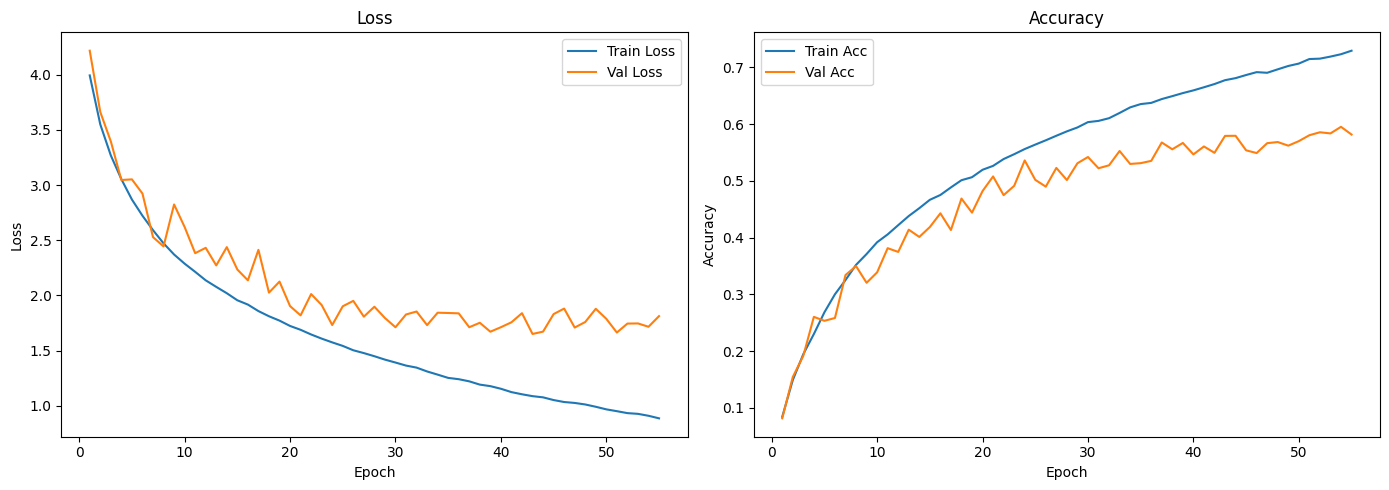

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  


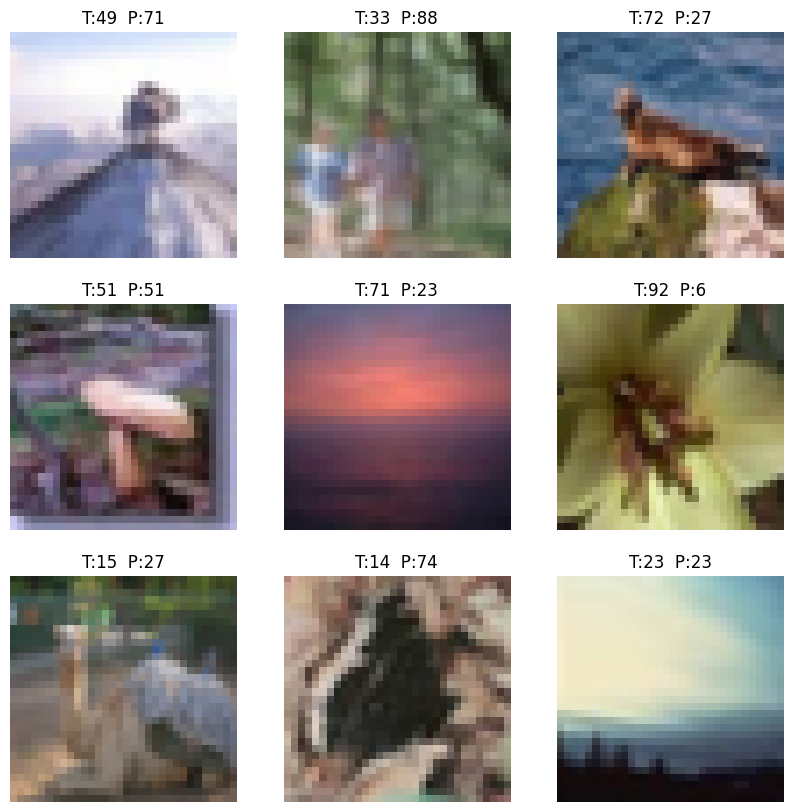

In [ ]:
# cifar100_deep_cnn_leakyrelu.py
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import os
import datetime

tf.random.set_seed(42)
np.random.seed(42)

# 1️⃣ Veri yükleme
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar100.load_data(label_mode='fine')
num_classes = 100

# Validation set (%10)
val_split = 0.1
num_val = int(len(x_train) * val_split)
x_val = x_train[:num_val]
y_val = y_train[:num_val]
x_train = x_train[num_val:]
y_train = y_train[num_val:]

print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")

# 2️⃣ Normalizasyon
x_train = x_train.astype("float32") / 255.0
x_val   = x_val.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# 3️⃣ Veri artırma
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.12),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.15),
], name="data_augmentation")

# 4️⃣ Model (ReLU yerine LeakyReLU)
def build_deep_cnn_leaky(input_shape=(32,32,3), num_classes=100):
    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)

    # Block 1
    x = layers.Conv2D(64, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Conv2D(64, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.15)(x)

    # Block 2
    x = layers.Conv2D(128, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Conv2D(128, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.2)(x)

    # Block 3
    x = layers.Conv2D(256, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Conv2D(256, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 4
    x = layers.Conv2D(512, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Conv2D(512, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.3)(x)

    # Extra Conv
    x = layers.Conv2D(1024, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)

    # Global pooling
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="deep_cifar100_cnn_leaky")
    return model

model = build_deep_cnn_leaky(input_shape=(32,32,3), num_classes=num_classes)
model.summary()

from tensorflow.keras.optimizers import AdamW

# 5️⃣ Derleme
optimizer = AdamW(learning_rate=1e-3, weight_decay=1e-4)
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 6️⃣ Callbacks
os.makedirs("checkpoints_leaky", exist_ok=True)
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
checkpoint_path = os.path.join("checkpoints_leaky", f"best_cifar100_leaky_{timestamp}.keras")

early_stopping = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)
model_checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)

# 7️⃣ Dataset pipeline
batch_size = 128
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(5000, seed=42).batch(batch_size).prefetch(AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(batch_size).prefetch(AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(batch_size).prefetch(AUTOTUNE)

# 8️⃣ Eğitim
epochs = 100
history = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# 9️⃣ En iyi modeli yükle
print("Best model checkpoint:", checkpoint_path)
best_model = keras.models.load_model(checkpoint_path)

# 🔟 Test değerlendirme
test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}   Test Accuracy: {test_acc:.4f}")

# 11️⃣ Grafikleri çiz
def plot_history(history):
    h = history.history
    epochs_range = range(1, len(h['loss']) + 1)

    plt.figure(figsize=(14,5))
    plt.subplot(1,2,1)
    plt.plot(epochs_range, h['loss'], label='Train Loss')
    plt.plot(epochs_range, h['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs_range, h['accuracy'], label='Train Acc')
    plt.plot(epochs_range, h['val_accuracy'], label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(history)

# 12️⃣ Örnek tahminler
import random
class_names = [f"class_{i}" for i in range(num_classes)]

x_batch, y_batch = next(iter(test_ds))
preds = best_model.predict(x_batch)
pred_class = np.argmax(preds, axis=1)

plt.figure(figsize=(10,10))
for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow((x_batch[i].numpy() * 255).astype("uint8"))
    plt.title(f"T:{int(y_batch[i])}  P:{int(pred_class[i])}")
    plt.axis("off")
plt.show()


Train: (45000, 32, 32, 3), Val: (5000, 32, 32, 3), Test: (10000, 32, 32, 3)


Model: "advanced_cifar100_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_26 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_112 (Conv2D)             │ (None, 32, 32, 64)     │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_113 (Conv2D)             │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_91 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_114 (Conv2D)             │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_115 (Conv2D)             │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_92 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_116 (Conv2D)             │ (None, 8, 8, 192)      │       221,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 8, 8, 192)      │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 8, 8, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_117 (Conv2D)             │ (None, 8, 8, 192)      │       331,776 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,984,740 (11.39 MB)

 Trainable params: 2,981,412 (11.37 MB)

 Non-trainable params: 3,328 (13.00 KB)

Epoch 1/120
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0106 - loss: 4.6452
Epoch 1: val_loss improved from inf to 4.60940, saving model to checkpoints_advanced/best_cifar100_swish_20251108-192545.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 24ms/step - accuracy: 0.0106 - loss: 4.6452 - val_accuracy: 0.0084 - val_loss: 4.6094 - learning_rate: 0.0010
Epoch 2/120
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0110 - loss: 4.6135
Epoch 2: val_loss did not improve from 4.60940
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.0110 - loss: 4.6135 - val_accuracy: 0.0084 - val_loss: 4.6960 - learning_rate: 0.0010
Epoch 3/120
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0101 - loss: 4.6149
Epoch 3: val_loss did not improve from 4.60940
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.0101 - loss: 4.6149 - val_accuracy: 0.0086 - val_loss: 4.6105 - learning_rate: 0.0010
Epoch 4/120
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0091 - loss: 4.614

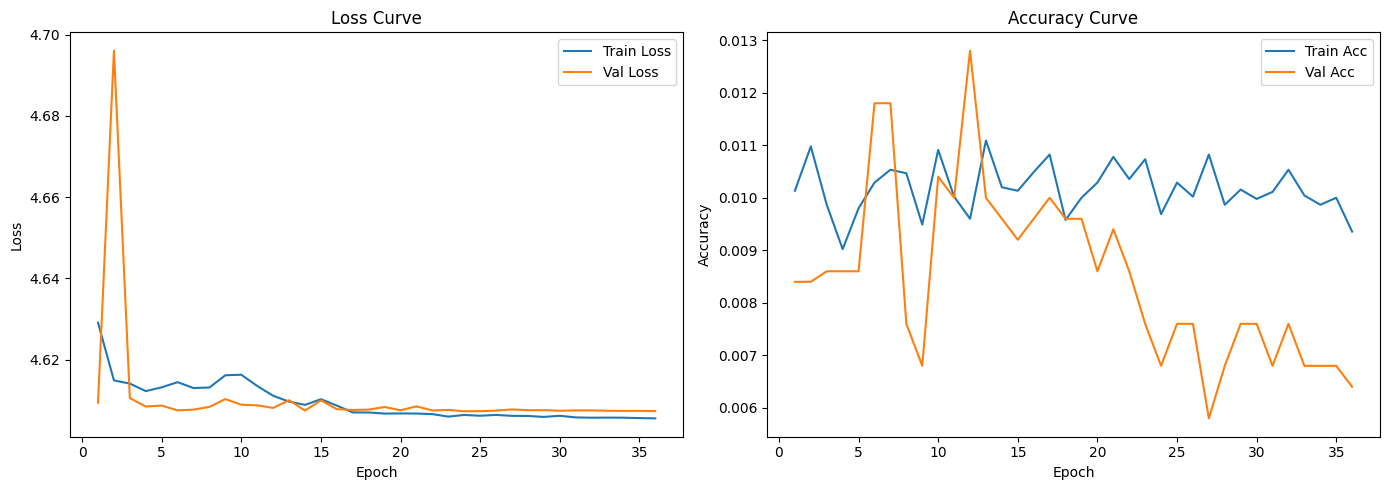

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step 


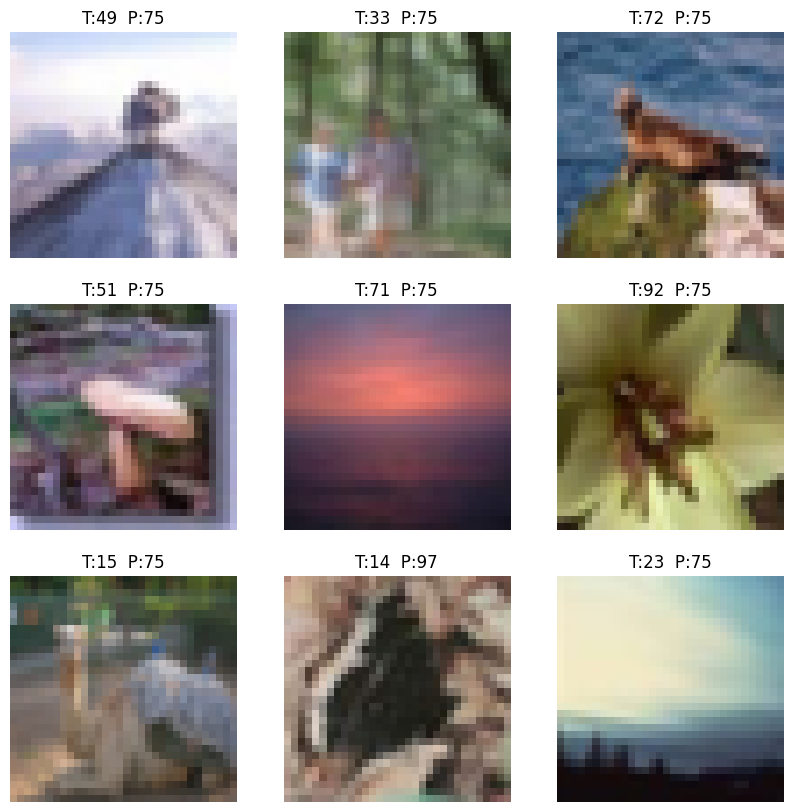

In [ ]:
# cifar100_advanced_cnn_swish_adamw.py
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import os
import datetime

# 🔒 Tekrarlanabilirlik
tf.random.set_seed(42)
np.random.seed(42)

# 1️⃣ Veri yükleme
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar100.load_data(label_mode='fine')
num_classes = 100

# Validation split (%10)
val_split = 0.1
num_val = int(len(x_train) * val_split)
x_val, y_val = x_train[:num_val], y_train[:num_val]
x_train, y_train = x_train[num_val:], y_train[num_val:]

print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")

# 2️⃣ Normalizasyon
x_train = x_train.astype("float32") / 255.0
x_val   = x_val.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# 3️⃣ Veri artırma (daha zengin)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.3),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
], name="data_augmentation")

# 4️⃣ Model (Swish aktivasyonu + AdamW + Dropout + BN)
def build_advanced_cnn(input_shape=(32,32,3), num_classes=100):
    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)

    # Blok 1
    x = layers.Conv2D(64, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("swish")(x)
    x = layers.Conv2D(64, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("swish")(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.15)(x)

    # Blok 2
    x = layers.Conv2D(128, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("swish")(x)
    x = layers.Conv2D(128, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("swish")(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.2)(x)

    # Blok 3
    x = layers.Conv2D(192, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("swish")(x)
    x = layers.Conv2D(192, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("swish")(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    # Blok 4
    x = layers.Conv2D(256, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("swish")(x)
    x = layers.Conv2D(256, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("swish")(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.3)(x)

    # Blok 5 (Ekstra derinlik)
    x = layers.Conv2D(384, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("swish")(x)

    x = layers.GlobalAveragePooling2D()(x)

    # Tam bağlantı katmanı
    x = layers.Dense(512)(x)
    x = layers.Activation("swish")(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="advanced_cifar100_cnn")

model = build_advanced_cnn()
model.summary()

# 5️⃣ Derleme (AdamW + ReduceLROnPlateau)
from tensorflow.keras.optimizers import AdamW
optimizer = AdamW(learning_rate=1e-3, weight_decay=1e-4)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 6️⃣ Callbacks
os.makedirs("checkpoints_advanced", exist_ok=True)
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
checkpoint_path = os.path.join("checkpoints_advanced", f"best_cifar100_swish_{timestamp}.keras")

early_stopping = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)
model_checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1, min_lr=1e-5)

# 7️⃣ Dataset pipeline
batch_size = 64   # Daha küçük batch → daha iyi genelleme
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(8000, seed=42).batch(batch_size).prefetch(AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(batch_size).prefetch(AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(batch_size).prefetch(AUTOTUNE)

# 8️⃣ Eğitim
epochs = 120
history = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=[early_stopping, model_checkpoint, reduce_lr],
    verbose=1
)

# 9️⃣ En iyi modeli yükle
print("Best model checkpoint:", checkpoint_path)
best_model = keras.models.load_model(checkpoint_path)

# 🔟 Test değerlendirme
test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f"\n✅ Test Loss: {test_loss:.4f}   Test Accuracy: {test_acc:.4f}")

# 11️⃣ Grafikleri çiz
def plot_history(history):
    h = history.history
    epochs_range = range(1, len(h['loss']) + 1)

    plt.figure(figsize=(14,5))
    plt.subplot(1,2,1)
    plt.plot(epochs_range, h['loss'], label='Train Loss')
    plt.plot(epochs_range, h['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Curve')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs_range, h['accuracy'], label='Train Acc')
    plt.plot(epochs_range, h['val_accuracy'], label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Curve')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(history)

# 12️⃣ Örnek tahminler
import random
class_names = [f"class_{i}" for i in range(num_classes)]

x_batch, y_batch = next(iter(test_ds))
preds = best_model.predict(x_batch)
pred_class = np.argmax(preds, axis=1)

plt.figure(figsize=(10,10))
for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow((x_batch[i].numpy() * 255).astype("uint8"))
    plt.title(f"T:{int(y_batch[i])}  P:{int(pred_class[i])}")
    plt.axis("off")
plt.show()


In [ ]:
!pip install tensorflow-addons
import tensorflow_addons as tfa


ERROR: Could not find a version that satisfies the requirement tensorflow-addons (from versions: none)
ERROR: No matching distribution found for tensorflow-addons


ModuleNotFoundError: No module named 'tensorflow_addons'

In [ ]:
!pip install --upgrade tensorflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 119.5 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Successfully uninstalled tensorboard-2.19.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.20.0 which is in

Train: (45000, 32, 32, 3), Val: (5000, 32, 32, 3), Test: (10000, 32, 32, 3)


Model: "optimized_cifar100_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       589,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 9,989,924 (38.11 MB)

 Trainable params: 9,984,036 (38.09 MB)

 Non-trainable params: 5,888 (23.00 KB)

Epoch 1/150
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0790 - loss: 4.3866
Epoch 1: val_loss improved from inf to 3.52651, saving model to checkpoints_optimized/best_cifar100_optimized_20251108-195438.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - accuracy: 0.0791 - loss: 4.3861 - val_accuracy: 0.2072 - val_loss: 3.5265 - learning_rate: 0.0100
Epoch 2/150
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2267 - loss: 3.4084
Epoch 2: val_loss improved from 3.52651 to 3.18305, saving model to checkpoints_optimized/best_cifar100_optimized_20251108-195438.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.2268 - loss: 3.4082 - val_accuracy: 0.2750 - val_loss: 3.1830 - learning_rate: 0.0100
Epoch 3/150
701/704 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3180 - loss: 2.9366
Epoch 3: val_loss improved from 3.18305 to 2.88962, saving model to checkpoints_optimized/best_cifar100_optimized_20251108-195438.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accurac

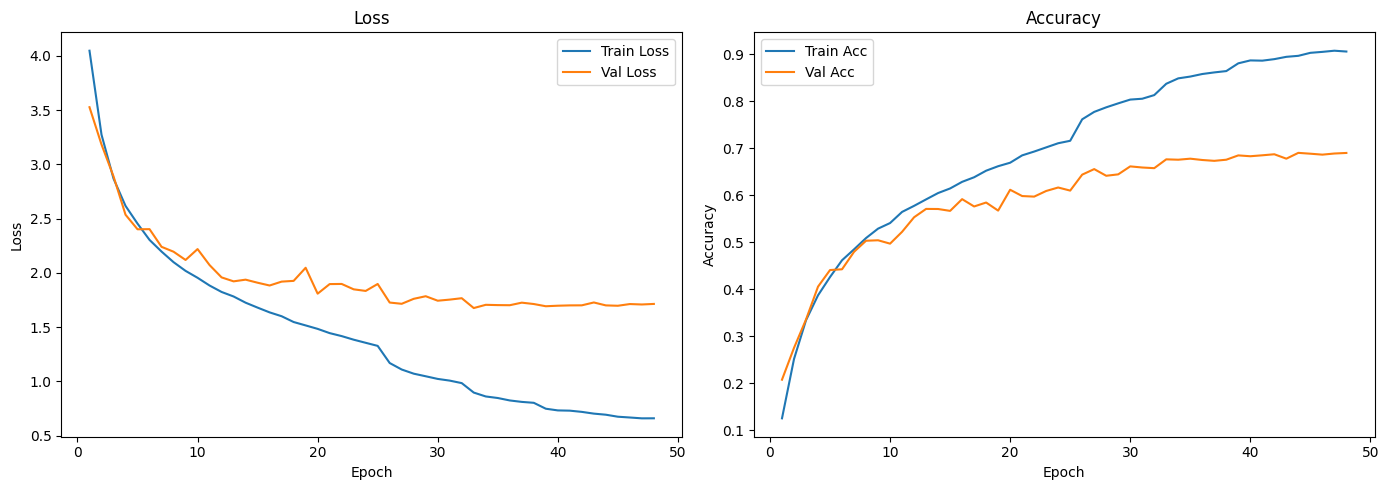

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step


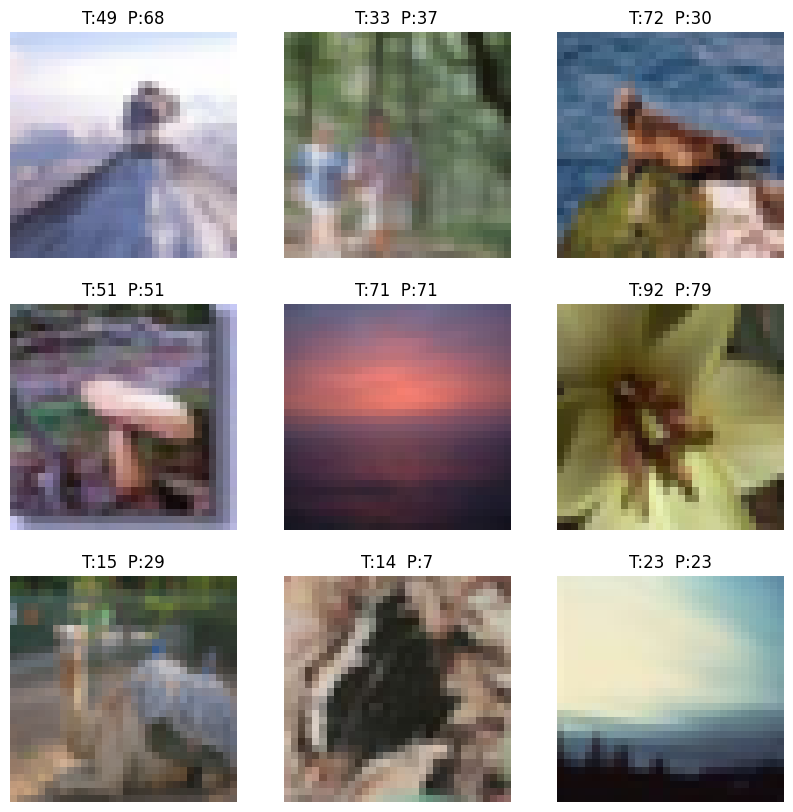

In [ ]:
# cifar100_optimized_cnn_pipeline.py
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import os
import datetime

tf.random.set_seed(42)
np.random.seed(42)

# 1️⃣ Veri yükleme
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar100.load_data(label_mode='fine')
num_classes = 100

# Validation set (%10)
val_split = 0.1
num_val = int(len(x_train) * val_split)
x_val = x_train[:num_val]
y_val = y_train[:num_val] # Corrected indexing
x_train = x_train[num_val:]
y_train = y_train[num_val:]

print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")

# 2️⃣ TensorFlow uyumlu Cutout fonksiyonu
def tf_random_cutout(image, mask_size=8):
    h, w = tf.shape(image)[0], tf.shape(image)[1]
    # Ensure mask size is not larger than image dimensions
    mask_size = tf.minimum(mask_size, tf.minimum(h, w))
    y = tf.random.uniform([], 0, h - mask_size + 1, dtype=tf.int32)
    x = tf.random.uniform([], 0, w - mask_size + 1, dtype=tf.int32)
    y1 = y
    y2 = y + mask_size
    x1 = x
    x2 = x + mask_size

    # Create a boolean mask for the cutout area
    grid_y = tf.tile(tf.range(h)[:, tf.newaxis], [1, w])
    grid_x = tf.tile(tf.range(w)[tf.newaxis, :], [h, 1])

    cutout_mask = tf.logical_and(tf.logical_and(grid_y >= y1, grid_y < y2),
                                 tf.logical_and(grid_x >= x1, grid_x < x2))

    cutout_mask = tf.expand_dims(cutout_mask, axis=-1) # Add channel dimension
    cutout_mask = tf.tile(cutout_mask, [1, 1, tf.shape(image)[-1]]) # Tile across channels

    # Invert the mask to keep the original image pixels outside the cutout area
    mask = tf.logical_not(cutout_mask)

    return tf.where(mask, image, tf.zeros_like(image))


# 3️⃣ Dataset pipeline + augmentation
batch_size = 64
AUTOTUNE = tf.data.AUTOTUNE

def preprocess_train(image, label):
    image = tf.cast(image, tf.float32)
    image = image / 255.0
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.85, 1.15)
    image = tf_random_cutout(image, mask_size=8) # Use the TF compatible cutout
    # Random translation can be added back using tf.image.affine_transform if needed,
    # but let's keep it simple for now to fix the cutout error.
    return image, label

def preprocess_val_test(image, label):
    image = tf.cast(image, tf.float32)
    image = image / 255.0
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(5000, seed=42).map(preprocess_train, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(batch_size).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = val_ds.map(preprocess_val_test).batch(batch_size).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.map(preprocess_val_test).batch(batch_size).prefetch(AUTOTUNE)

# 4️⃣ Model mimarisi
def build_optimized_cnn(input_shape=(32,32,3), num_classes=100):
    inputs = layers.Input(shape=input_shape)
    x = inputs

    # Conv bloklar
    filters_list = [64, 128, 256, 512]
    dropout_list = [0.15, 0.2, 0.25, 0.3]

    for filters, dropout_rate in zip(filters_list, dropout_list):
        x = layers.Conv2D(filters, (3,3), padding="same",
                          kernel_regularizer=keras.regularizers.l2(1e-4),
                          use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("swish")(x)
        x = layers.Conv2D(filters, (3,3), padding="same",
                          kernel_regularizer=keras.regularizers.l2(1e-4),
                          use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("swish")(x)
        x = layers.MaxPooling2D((2,2))(x)
        x = layers.Dropout(dropout_rate)(x)

    # Extra conv
    x = layers.Conv2D(1024, (3,3), padding="same",
                      kernel_regularizer=keras.regularizers.l2(1e-4),
                      use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("swish")(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Activation("swish")(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="optimized_cifar100_cnn")

model = build_optimized_cnn()
model.summary()

# 5️⃣ Derleme
optimizer = keras.optimizers.SGD(learning_rate=1e-2, momentum=0.9, nesterov=True)
model.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

# 6️⃣ Callbacks
os.makedirs("checkpoints_optimized", exist_ok=True)
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
checkpoint_path = os.path.join("checkpoints_optimized", f"best_cifar100_optimized_{timestamp}.keras")

early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
model_checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# 7️⃣ Eğitim
epochs = 150
history = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=[early_stopping, model_checkpoint, reduce_lr],
    verbose=1
)

# 8️⃣ En iyi modeli yükle
print("Best model checkpoint:", checkpoint_path)
best_model = keras.models.load_model(checkpoint_path)

# 9️⃣ Test değerlendirme
test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}   Test Accuracy: {test_acc:.4f}")

# 🔟 Eğitim grafikleri
def plot_history(history):
    h = history.history
    epochs_range = range(1, len(h['loss']) + 1)

    plt.figure(figsize=(14,5))
    plt.subplot(1,2,1)
    plt.plot(epochs_range, h['loss'], label='Train Loss')
    plt.plot(epochs_range, h['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs_range, h['accuracy'], label='Train Acc')
    plt.plot(epochs_range, h['val_accuracy'], label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(history)

# 11️⃣ Örnek tahminler
x_batch, y_batch = next(iter(test_ds))
preds = best_model.predict(x_batch)
pred_class = np.argmax(preds, axis=1)

plt.figure(figsize=(10,10))
for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow((x_batch[i].numpy() * 255).astype("uint8"))
    plt.title(f"T:{int(y_batch[i])}  P:{int(pred_class[i])}")
    plt.axis("off")
plt.show()

**DENSE121**

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Train: (45000, 32, 32, 3), Val: (5000, 32, 32, 3), Test: (10000, 32, 32, 3)


Model: "DenseNet121_CIFAR100"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       102,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,140,004 (27.24 MB)

 Trainable params: 7,056,356 (26.92 MB)

 Non-trainable params: 83,648 (326.75 KB)

Epoch 1/150
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.0531 - loss: 4.4970
Epoch 1: val_loss improved from inf to 126.76222, saving model to checkpoints_densenet/best_densenet121_cifar100_20251109-212947.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 267s 174ms/step - accuracy: 0.0531 - loss: 4.4966 - val_accuracy: 0.0234 - val_loss: 126.7622 - learning_rate: 0.0010
Epoch 2/150
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1168 - loss: 3.8636
Epoch 2: val_loss improved from 126.76222 to 7.26077, saving model to checkpoints_densenet/best_densenet121_cifar100_20251109-212947.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.1169 - loss: 3.8633 - val_accuracy: 0.1044 - val_loss: 7.2608 - learning_rate: 0.0010
Epoch 3/150
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1741 - loss: 3.4499
Epoch 3: val_loss improved from 7.26077 to 3.57430, saving model to checkpoints_densenet/best_densenet121_cifar100_20251109-212947.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 3

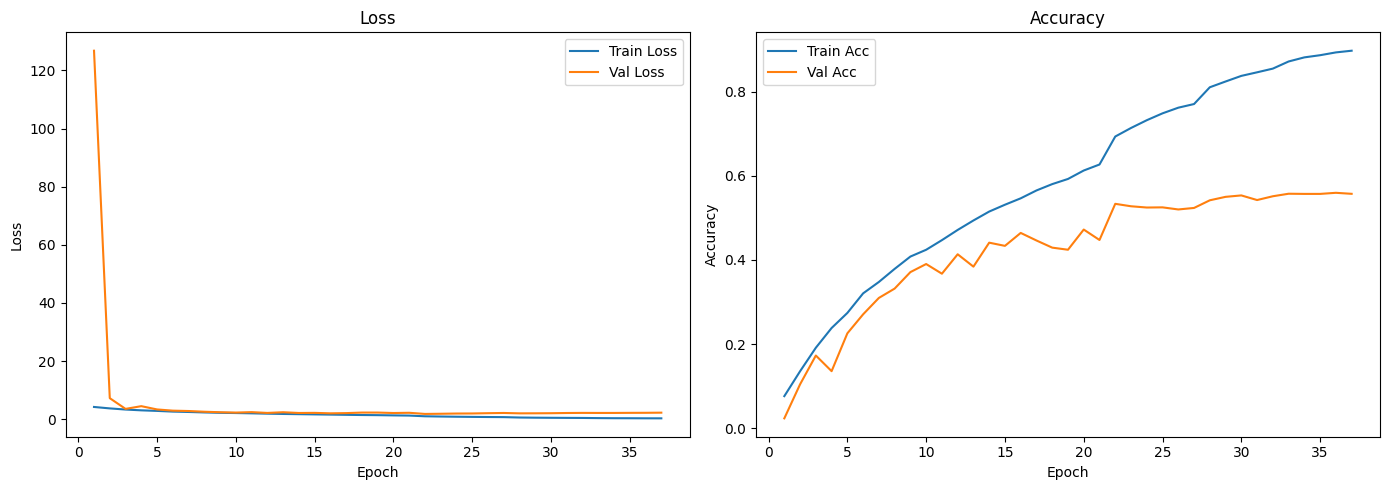

In [1]:
# cifar100_densenet121.py
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import os
import datetime

tf.random.set_seed(42)
np.random.seed(42)

# 1️⃣ Veri yükleme
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar100.load_data(label_mode='fine')
num_classes = 100

# Validation set (%10)
val_split = 0.1
num_val = int(len(x_train) * val_split)
x_val = x_train[:num_val]
y_val = y_train[:num_val]
x_train = x_train[num_val:]
y_train = y_train[num_val:]

print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")

# 2️⃣ TF Cutout (aynı kalıyor)
def tf_random_cutout(image, mask_size=8):
    h, w = tf.shape(image)[0], tf.shape(image)[1]
    mask_size = tf.minimum(mask_size, tf.minimum(h, w))
    y = tf.random.uniform([], 0, h - mask_size + 1, dtype=tf.int32)
    x = tf.random.uniform([], 0, w - mask_size + 1, dtype=tf.int32)
    y1, y2 = y, y + mask_size
    x1, x2 = x, x + mask_size
    grid_y = tf.tile(tf.range(h)[:, tf.newaxis], [1, w])
    grid_x = tf.tile(tf.range(w)[tf.newaxis, :], [h, 1])
    cutout_mask = tf.logical_and(tf.logical_and(grid_y >= y1, grid_y < y2),
                                 tf.logical_and(grid_x >= x1, grid_x < x2))
    cutout_mask = tf.expand_dims(cutout_mask, axis=-1)
    cutout_mask = tf.tile(cutout_mask, [1, 1, tf.shape(image)[-1]])
    mask = tf.logical_not(cutout_mask)
    return tf.where(mask, image, tf.zeros_like(image))

# 3️⃣ Dataset pipeline
batch_size = 64
AUTOTUNE = tf.data.AUTOTUNE

def preprocess_train(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.85, 1.15)
    image = tf_random_cutout(image, mask_size=8)
    return image, label

def preprocess_val_test(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(5000, seed=42).map(preprocess_train, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(batch_size).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = val_ds.map(preprocess_val_test).batch(batch_size).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.map(preprocess_val_test).batch(batch_size).prefetch(AUTOTUNE)

# 4️⃣ DenseNet121 tabanlı model
def build_densenet121_cifar100(input_shape=(32, 32, 3), num_classes=100):
    # DenseNet121 normalde 224x224 için tasarlanmıştır.
    # CIFAR-100 daha küçük olduğu için include_top=False kullanıyoruz.
    base_model = keras.applications.DenseNet121(
        include_top=False,
        weights=None,  # CIFAR için sıfırdan eğitilecek
        input_shape=input_shape,
        pooling='avg'  # Global Average Pooling otomatik
    )

    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=True)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs, outputs, name='DenseNet121_CIFAR100')
    return model

model = build_densenet121_cifar100()
model.summary()

# 5️⃣ Derleme
optimizer = keras.optimizers.Adam(learning_rate=1e-3)
model.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

# 6️⃣ Callbacks
os.makedirs("checkpoints_densenet", exist_ok=True)
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
checkpoint_path = os.path.join("checkpoints_densenet", f"best_densenet121_cifar100_{timestamp}.keras")

early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
model_checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# 7️⃣ Eğitim
epochs = 150
history = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=[early_stopping, model_checkpoint, reduce_lr],
    verbose=1
)

# 8️⃣ En iyi modeli yükle
print("Best model checkpoint:", checkpoint_path)
best_model = keras.models.load_model(checkpoint_path)

# 9️⃣ Test değerlendirme
test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}   Test Accuracy: {test_acc:.4f}")

# 🔟 Eğitim grafikleri
def plot_history(history):
    h = history.history
    epochs_range = range(1, len(h['loss']) + 1)
    plt.figure(figsize=(14,5))
    plt.subplot(1,2,1)
    plt.plot(epochs_range, h['loss'], label='Train Loss')
    plt.plot(epochs_range, h['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss')
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs_range, h['accuracy'], label='Train Acc')
    plt.plot(epochs_range, h['val_accuracy'], label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(history)


Train: (45000, 32, 32, 3), Val: (5000, 32, 32, 3), Test: (10000, 32, 32, 3)
74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "DenseNet201_CIFAR100"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet201 (Functional)        │ (None, 1920)           │    18,321,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       983,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,356,836 (73.84 MB)

 Trainable params: 1,034,852 (3.95 MB)

 Non-trainable params: 18,321,984 (69.89 MB)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.3824 - loss: 2.5138
Epoch 1: val_loss improved from inf to 1.43925, saving model to checkpoints_densenet201/best_densenet201_cifar100_20251109-220416.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 168s 157ms/step - accuracy: 0.3826 - loss: 2.5130 - val_accuracy: 0.5930 - val_loss: 1.4393 - learning_rate: 0.0010
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6050 - loss: 1.4013
Epoch 2: val_loss improved from 1.43925 to 1.32915, saving model to checkpoints_densenet201/best_densenet201_cifar100_20251109-220416.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - accuracy: 0.6050 - loss: 1.4013 - val_accuracy: 0.6280 - val_loss: 1.3291 - learning_rate: 0.0010
Epoch 3/50
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6394 - loss: 1.2429
Epoch 3: val_loss improved from 1.32915 to 1.29382, saving model to checkpoints_densenet201/best_densenet201_cifar100_20251109-220416.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 55

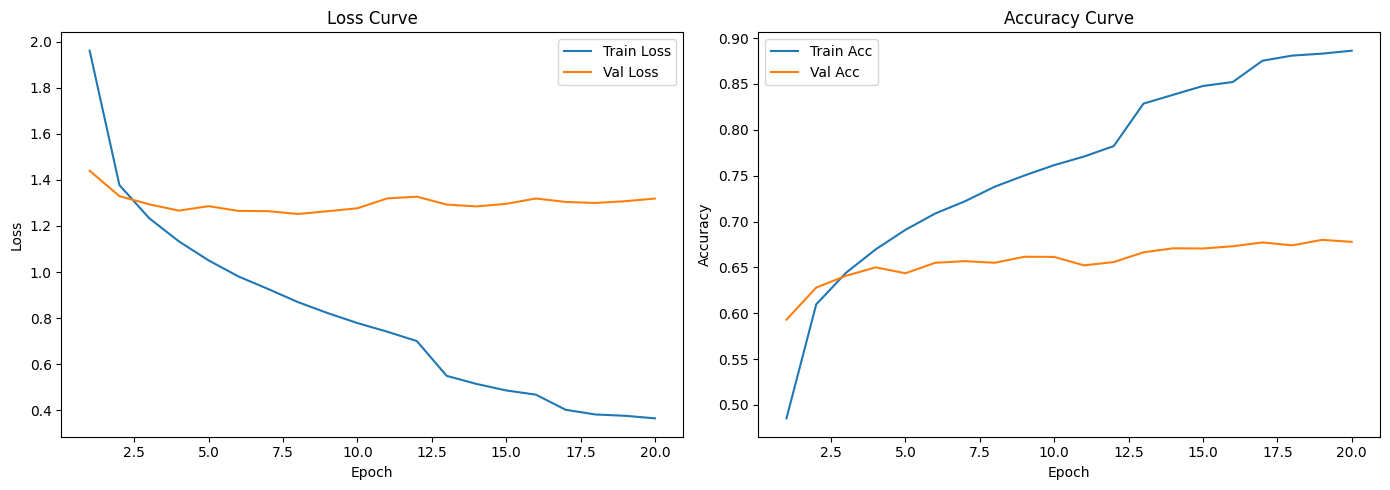

2/2 ━━━━━━━━━━━━━━━━━━━━ 32s 53ms/step


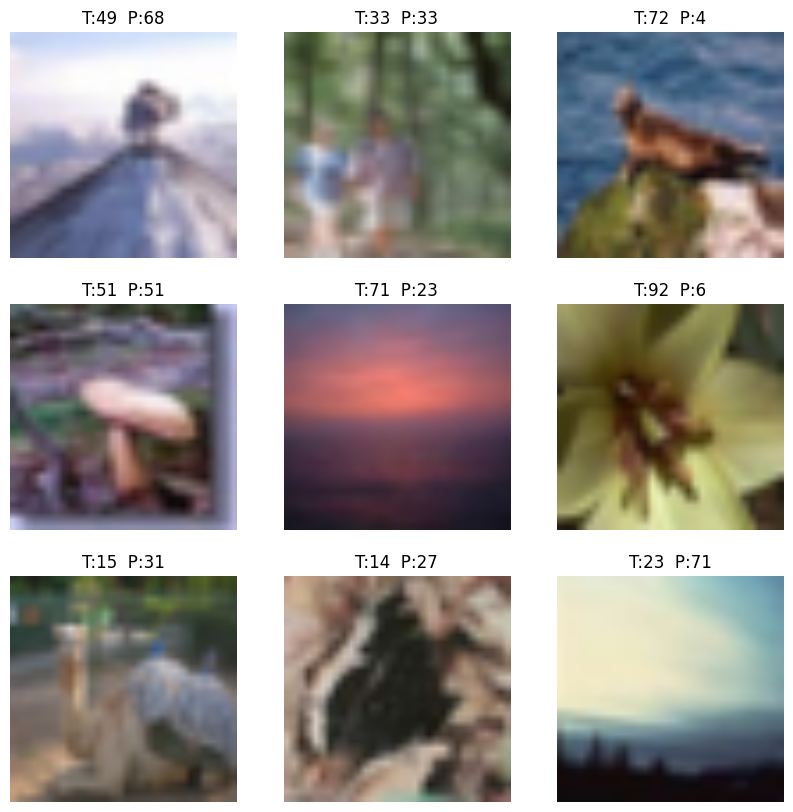

In [2]:
# cifar100_densenet201.py
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import os
import datetime

tf.random.set_seed(42)
np.random.seed(42)

# =====================================================
# 1️⃣ Veri yükleme
# =====================================================
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar100.load_data(label_mode='fine')
num_classes = 100

# Validation set (%10)
val_split = 0.1
num_val = int(len(x_train) * val_split)
x_val = x_train[:num_val]
y_val = y_train[:num_val]
x_train = x_train[num_val:]
y_train = y_train[num_val:]

print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")

# =====================================================
# 2️⃣ Görüntü boyutlarını DenseNet201 için 224x224 yap
# =====================================================
IMG_SIZE = 224
batch_size = 64
AUTOTUNE = tf.data.AUTOTUNE

def resize_and_augment(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    return image, label

def resize_only(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(5000, seed=42).map(resize_and_augment, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(batch_size).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = val_ds.map(resize_only).batch(batch_size).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.map(resize_only).batch(batch_size).prefetch(AUTOTUNE)

# =====================================================
# 3️⃣ DenseNet201 modelini oluştur
# =====================================================
def build_densenet201_cifar100(input_shape=(224, 224, 3), num_classes=100):
    base_model = keras.applications.DenseNet201(
        include_top=False,
        weights="imagenet",   # Ön eğitimli ağırlıklar
        input_shape=input_shape,
        pooling="avg"         # GlobalAveragePooling otomatik
    )

    # Base model'i donduruyoruz (sadece son katmanları eğit)
    base_model.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.Dense(512, activation="swish")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="DenseNet201_CIFAR100")
    return model

model = build_densenet201_cifar100()
model.summary()

# =====================================================
# 4️⃣ Derleme
# =====================================================
optimizer = keras.optimizers.Adam(learning_rate=1e-3)
model.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

# =====================================================
# 5️⃣ Callbacks
# =====================================================
os.makedirs("checkpoints_densenet201", exist_ok=True)
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
checkpoint_path = os.path.join("checkpoints_densenet201", f"best_densenet201_cifar100_{timestamp}.keras")

early_stopping = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)
model_checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)

# =====================================================
# 6️⃣ Eğitim
# =====================================================
epochs = 50
history = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=[early_stopping, model_checkpoint, reduce_lr],
    verbose=1
)

# =====================================================
# 7️⃣ En iyi modeli yükle
# =====================================================
print("Best model checkpoint:", checkpoint_path)
best_model = keras.models.load_model(checkpoint_path)

# =====================================================
# 8️⃣ Test değerlendirme
# =====================================================
test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f"\n✅ Test Loss: {test_loss:.4f}   Test Accuracy: {test_acc:.4f}")

# =====================================================
# 9️⃣ Eğitim grafikleri
# =====================================================
def plot_history(history):
    h = history.history
    epochs_range = range(1, len(h["loss"]) + 1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, h["loss"], label="Train Loss")
    plt.plot(epochs_range, h["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss Curve")

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, h["accuracy"], label="Train Acc")
    plt.plot(epochs_range, h["val_accuracy"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Accuracy Curve")
    plt.tight_layout()
    plt.show()

plot_history(history)

# =====================================================
# 🔟 Örnek tahminler
# =====================================================
x_batch, y_batch = next(iter(test_ds))
preds = best_model.predict(x_batch)
pred_class = np.argmax(preds, axis=1)

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow((x_batch[i].numpy() * 255).astype("uint8"))
    plt.title(f"T:{int(y_batch[i])}  P:{int(pred_class[i])}")
    plt.axis("off")
plt.show()


Train: (45000, 32, 32, 3), Val: (5000, 32, 32, 3), Test: (10000, 32, 32, 3)


Model: "DenseNet264_Custom"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_4    │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_4… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_5    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_5… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 93,681,316 (357.37 MB)

 Trainable params: 93,444,068 (356.46 MB)

 Non-trainable params: 237,248 (926.75 KB)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 759ms/step - accuracy: 0.1788 - loss: 3.4132
Epoch 1: val_loss improved from inf to 2.69630, saving model to checkpoints_densenet264_custom/best_densenet264_20251109-222831.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 1052s 834ms/step - accuracy: 0.1789 - loss: 3.4123 - val_accuracy: 0.3144 - val_loss: 2.6963 - learning_rate: 0.0010
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.4587 - loss: 1.9122
Epoch 2: val_loss improved from 2.69630 to 2.05979, saving model to checkpoints_densenet264_custom/best_densenet264_20251109-222831.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 127s 180ms/step - accuracy: 0.4588 - loss: 1.9120 - val_accuracy: 0.4662 - val_loss: 2.0598 - learning_rate: 0.0010
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.5637 - loss: 1.5007
Epoch 3: val_loss improved from 2.05979 to 1.99586, saving model to checkpoints_densenet264_custom/best_densenet264_20251109-222831.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 127s 1

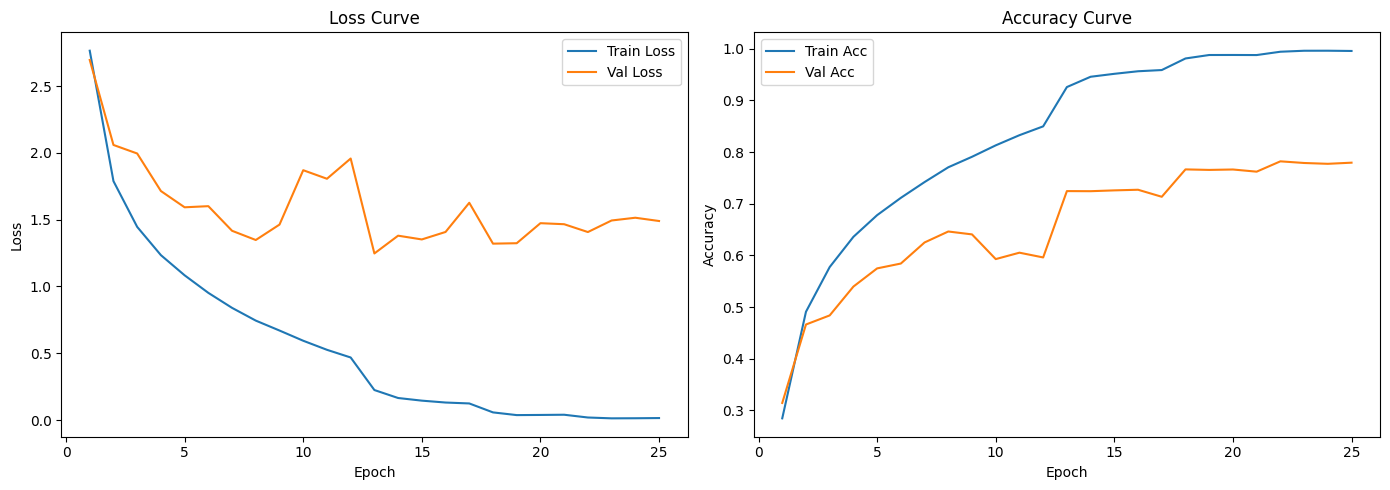

2/2 ━━━━━━━━━━━━━━━━━━━━ 28s 59ms/step


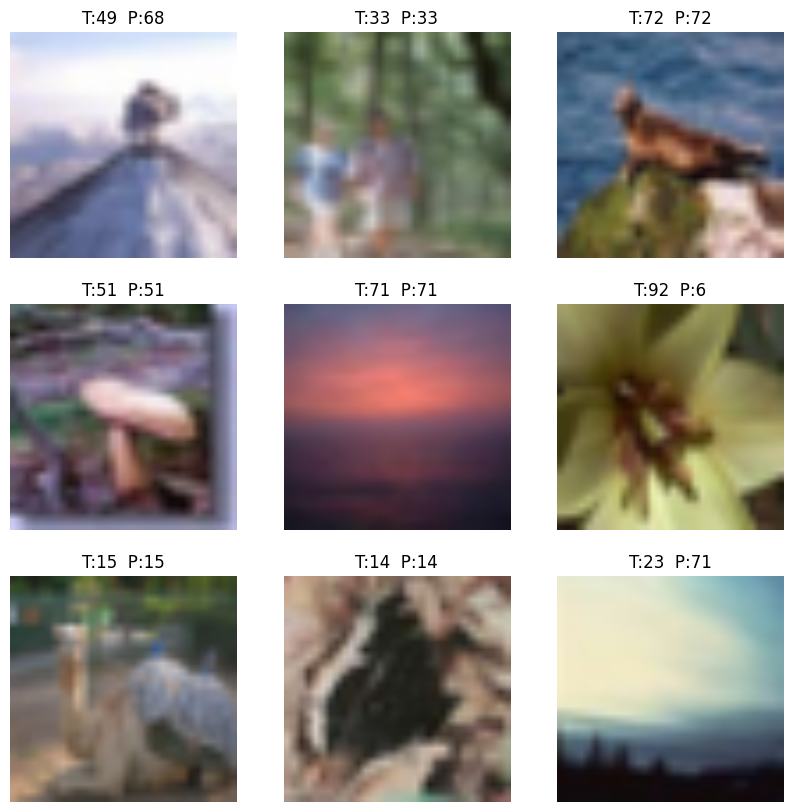

In [4]:
# cifar100_densenet264_custom.py
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import os
import datetime

tf.random.set_seed(42)
np.random.seed(42)

# =====================================================
# 1️⃣ Veri yükleme
# =====================================================
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar100.load_data(label_mode='fine')
num_classes = 100

# Validation %10
val_split = 0.1
num_val = int(len(x_train) * val_split)
x_val = x_train[:num_val]
y_val = y_train[:num_val]
x_train = x_train[num_val:]
y_train = y_train[num_val:]

print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")

# =====================================================
# 2️⃣ Veri ön işleme
# =====================================================
IMG_SIZE = 224
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

def resize_and_augment(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    return image, label

def resize_only(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(5000).map(resize_and_augment, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = val_ds.map(resize_only).batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.map(resize_only).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# =====================================================
# 3️⃣ DenseNet201 tabanlı “DenseNet264-benzeri” model
# =====================================================
def build_densenet264_custom(input_shape=(224, 224, 3), num_classes=100):
    # DenseNet201 tabanını al
    base_model = keras.applications.DenseNet201(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape,
        pooling=None  # kendimiz global avg ekleyeceğiz
    )

    # Bazı katmanları “DenseNet264 yoğunluğuna” yakınlaştırmak için ek bloklar ekle
    x = base_model.output
    x = layers.Conv2D(2048, (3,3), padding="same", activation="swish")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(2048, (3,3), padding="same", activation="swish")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(1024, activation="swish")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs=base_model.input, outputs=outputs, name="DenseNet264_Custom")
    return model

model = build_densenet264_custom()
model.summary()

# =====================================================
# 4️⃣ Derleme
# =====================================================
optimizer = keras.optimizers.Adam(learning_rate=1e-3)
model.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

# =====================================================
# 5️⃣ Callbacks
# =====================================================
os.makedirs("checkpoints_densenet264_custom", exist_ok=True)
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
checkpoint_path = os.path.join("checkpoints_densenet264_custom", f"best_densenet264_{timestamp}.keras")

early_stopping = EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True, verbose=1)
model_checkpoint = ModelCheckpoint(checkpoint_path, monitor="val_loss", save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1)

# =====================================================
# 6️⃣ Eğitim
# =====================================================
EPOCHS = 50
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[early_stopping, model_checkpoint, reduce_lr],
    verbose=1
)

# =====================================================
# 7️⃣ En iyi modeli yükle
# =====================================================
print(f"Best model saved at: {checkpoint_path}")
best_model = keras.models.load_model(checkpoint_path)

# =====================================================
# 8️⃣ Test değerlendirme
# =====================================================
test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f"\n✅ Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

# =====================================================
# 9️⃣ Eğitim grafikleri
# =====================================================
def plot_history(history):
    h = history.history
    epochs_range = range(1, len(h["loss"]) + 1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, h["loss"], label="Train Loss")
    plt.plot(epochs_range, h["val_loss"], label="Val Loss")
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, h["accuracy"], label="Train Acc")
    plt.plot(epochs_range, h["val_accuracy"], label="Val Acc")
    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

# =====================================================
# 🔟 Örnek tahminler
# =====================================================
x_batch, y_batch = next(iter(test_ds))
preds = best_model.predict(x_batch)
pred_class = np.argmax(preds, axis=1)

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow((x_batch[i].numpy() * 255).astype("uint8"))
    plt.title(f"T:{int(y_batch[i])}  P:{int(pred_class[i])}")
    plt.axis("off")
plt.show()
